In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

#sns.set_style("whitegrid")


In [3]:
os.chdir("/home/yogeshwar10/Data Science Projects/satellite-property-valuation")

In [4]:
df_train = pd.read_csv("data/processed/train_tabular_processed.csv")
df_train.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,lat,long,sqft_living15,sqft_lot15,year,month,day,day_of_week,is_renovated,log_price
0,268643,4,2.25,1810,9240,2.0,0,0,3,7,...,47.4362,-122.187,1660,9240,2015,5,5,1,0,12.501139
1,245000,3,2.50,1600,2788,2.0,0,0,4,7,...,47.4034,-122.187,1720,3605,2014,7,8,1,0,12.409013
2,200000,4,2.50,1720,8638,2.0,0,0,3,8,...,47.2704,-122.313,1870,7455,2015,1,15,3,0,12.206073
3,352499,2,2.25,1240,705,2.0,0,0,3,7,...,47.5321,-122.073,1240,750,2015,4,27,0,0,12.772803
4,232000,3,2.00,1280,13356,1.0,0,0,3,7,...,47.3715,-122.074,1590,8071,2014,12,5,4,0,12.354493


In [5]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16209 entries, 0 to 16208
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   price          16209 non-null  int64  
 1   bedrooms       16209 non-null  int64  
 2   bathrooms      16209 non-null  float64
 3   sqft_living    16209 non-null  int64  
 4   sqft_lot       16209 non-null  int64  
 5   floors         16209 non-null  float64
 6   waterfront     16209 non-null  int64  
 7   view           16209 non-null  int64  
 8   condition      16209 non-null  int64  
 9   grade          16209 non-null  int64  
 10  sqft_above     16209 non-null  int64  
 11  sqft_basement  16209 non-null  int64  
 12  yr_built       16209 non-null  int64  
 13  yr_renovated   16209 non-null  int64  
 14  lat            16209 non-null  float64
 15  long           16209 non-null  float64
 16  sqft_living15  16209 non-null  int64  
 17  sqft_lot15     16209 non-null  int64  
 18  year  

In [ ]:
X = df_train.drop(columns=["price", "log_price"])
y = df_train["log_price"]

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)


In [10]:
from sklearn.metrics import root_mean_squared_error


def evaluate_model(y_true_log, y_pred_log):
    """
    Evaluate on original price scale.
    """
    y_true = np.exp(y_true_log)
    y_pred = np.exp(y_pred_log)

    rmse = root_mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    return rmse, r2


In [11]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_val)

rmse_lr, r2_lr = evaluate_model(y_val, y_pred_lr)
rmse_lr, r2_lr


(175825.37159711885, 0.7536464765751049)

In [12]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_val)

rmse_rf, r2_rf = evaluate_model(y_val, y_pred_rf)
rmse_rf, r2_rf


(134603.23809551398, 0.8556201103639114)

In [13]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "RMSE": [rmse_lr, rmse_rf],
    "R2": [r2_lr, r2_rf],
})

results


,Model,RMSE,R2
0,Linear Regression,175825.371597,0.753646
1,Random Forest,134603.238096,0.855620


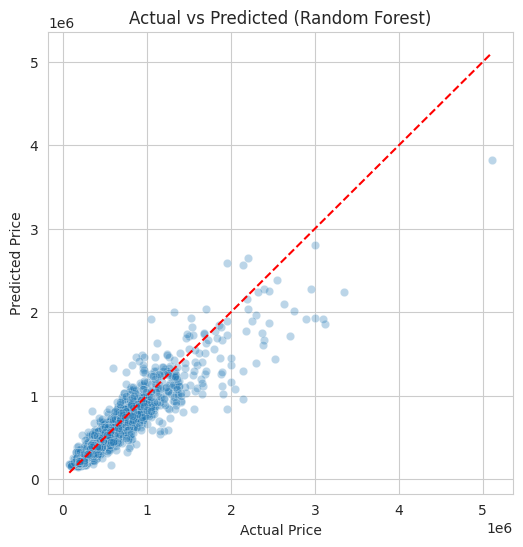

In [15]:
y_val_price = np.exp(y_val)
y_pred_price = np.exp(y_pred_rf)

plt.figure(figsize=(6,6))
sns.scatterplot(x=y_val_price, y=y_pred_price, alpha=0.3)
plt.plot(
    [y_val_price.min(), y_val_price.max()],
    [y_val_price.min(), y_val_price.max()],
    linestyle="--",
    color="red",
)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted (Random Forest)")
plt.show()


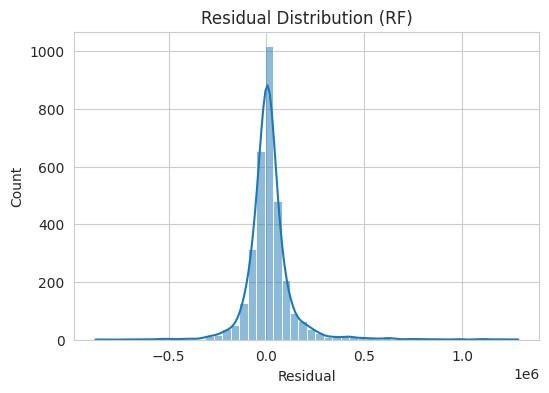

In [16]:
residuals = y_val_price - y_pred_price

plt.figure(figsize=(6,4))
sns.histplot(residuals, bins=50, kde=True)
plt.title("Residual Distribution (RF)")
plt.xlabel("Residual")
plt.show()


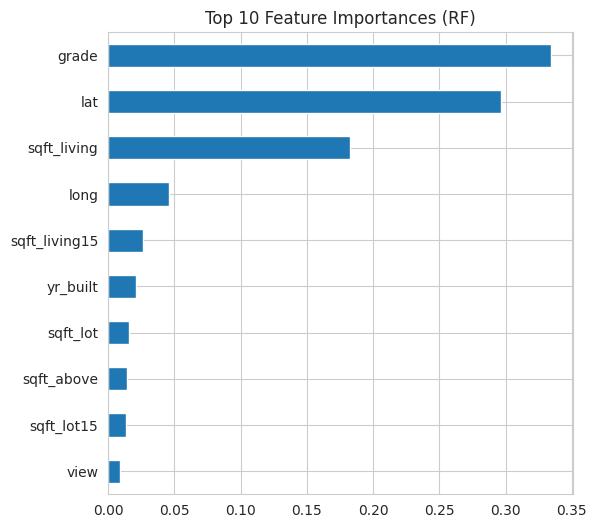

In [17]:
importances = pd.Series(
    rf.feature_importances_,
    index=X_train.columns,
).sort_values(ascending=False)

plt.figure(figsize=(6,6))
importances.head(10).plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importances (RF)")
plt.show()
